In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Paths
REPO_ROOT = Path('/Users/trevin/Git/ucsd-phys-139-final')
DATA_DIR = REPO_ROOT / 'data'

# Files
SCORES_PATH = DATA_DIR / 'anomaly_scores.csv'
CSV_PATTERN = 'features_batch_*.csv'

# Load anomaly scores
scores = pd.read_csv(SCORES_PATH)
print('Scores shape:', scores.shape)
print(scores.head())

# Load feature CSVs and concatenate
csv_paths = sorted(DATA_DIR.glob(CSV_PATTERN))
assert csv_paths, f'No CSV files matching {CSV_PATTERN!r} found in {DATA_DIR}'

feature_dfs = [pd.read_csv(p) for p in csv_paths]
features = pd.concat(feature_dfs, ignore_index=True)
print('Features shape:', features.shape)
print(features.head())

# Ensure we have a common ID column name
if 'star_id' in features.columns:
    features = features.rename(columns={'star_id': 'id'})

# Merge on ID
df = features.merge(scores, on='id', how='inner')
print('Merged shape:', df.shape)

# Identify feature columns (exclude id and anomaly metadata)
feature_cols = [c for c in df.columns if c not in ['id', 'anomaly_score', 'is_anomaly']]
print('Feature columns:', feature_cols)

sns.set(style='whitegrid')


Scores shape: (8943, 3)
          id  anomaly_score  is_anomaly
0  130943601       0.808543        True
1   55298910       0.779808        True
2  163024899       0.763222        True
3  107139259       0.760154        True
4   80840548       0.752635        True
Features shape: (8943, 13)
   star_id    period         Q31           Amp         W         K  \
0  1627611  0.000694   17.367676  2.725798e+07  0.995328  0.790877   
1  1627709  0.001388   31.924316  1.753971e+01  0.998039  0.789019   
2  1628071  0.001385  632.500000  4.369893e+02  0.960232  0.769158   
3  1628320  0.000694   91.816406  1.380857e+02  0.990501  0.766467   
4  1628550  0.000704   13.359497  1.861681e+00  0.999504  0.793396   

          Std    gamma1     gamma2       R21       R31     phi21     phi31  
0   13.129725  0.234567   0.896274  0.740679  0.444024 -3.142877 -6.288401  
1   24.264444  0.136627   0.381863  0.490034  0.354283  1.982006  1.376225  
2  492.486649  1.294851  24.418117  0.140090  0.234802 -5

Using random subsample of 2000 rows for plotting (of 8943)


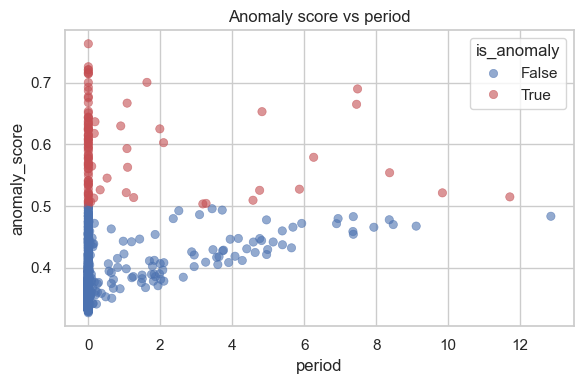

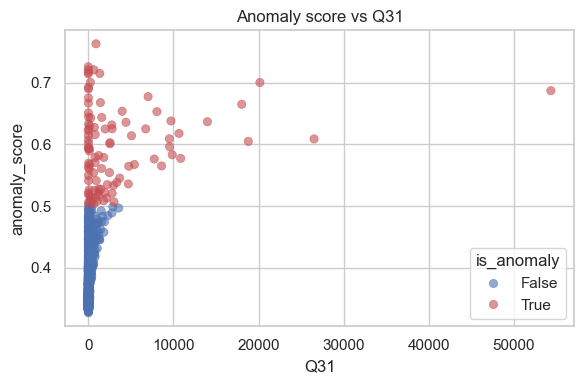

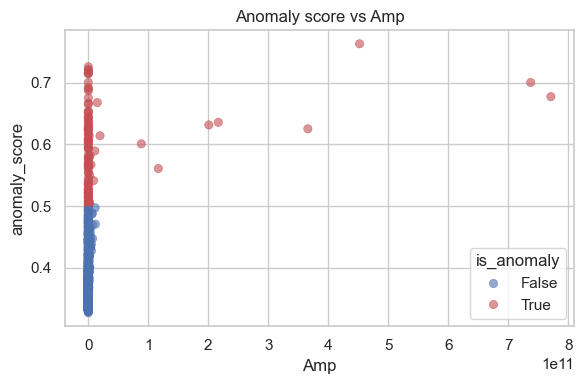

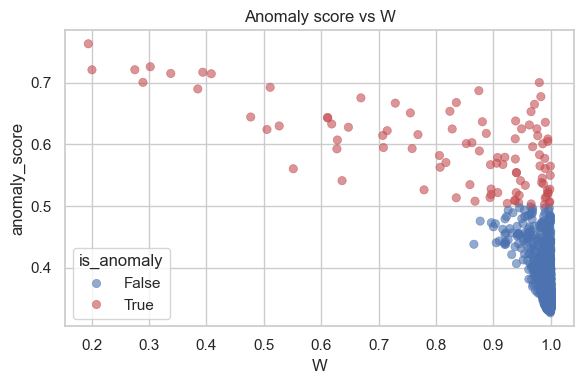

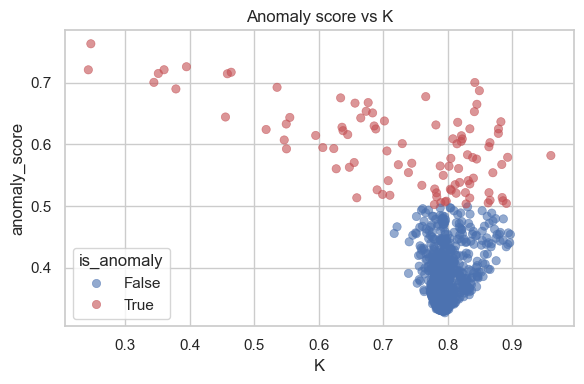

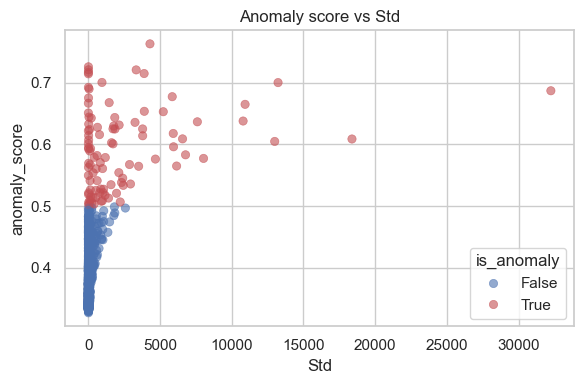

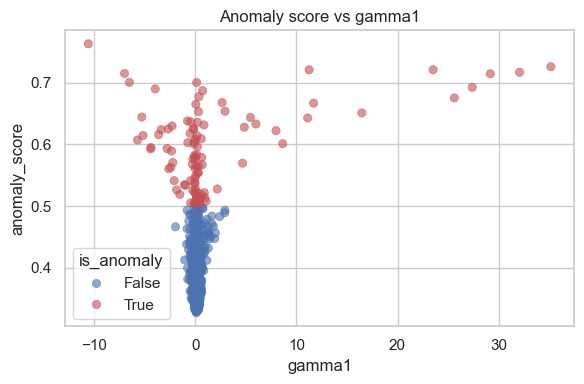

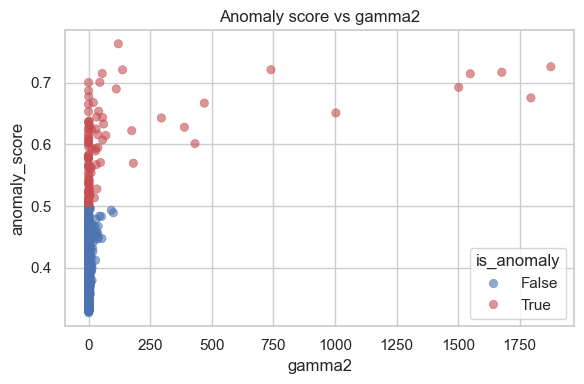

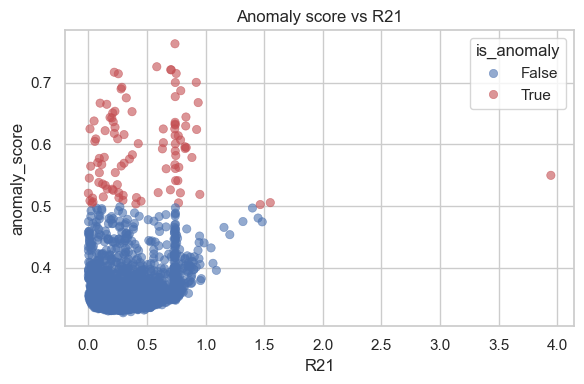

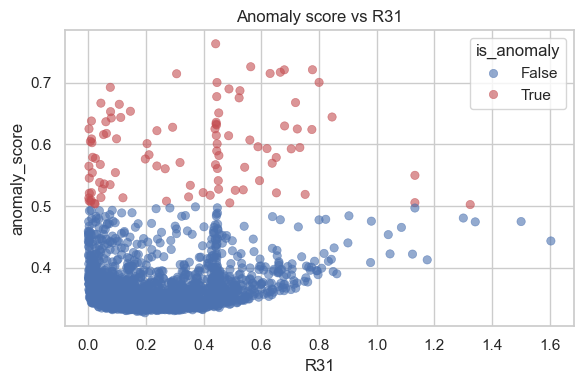

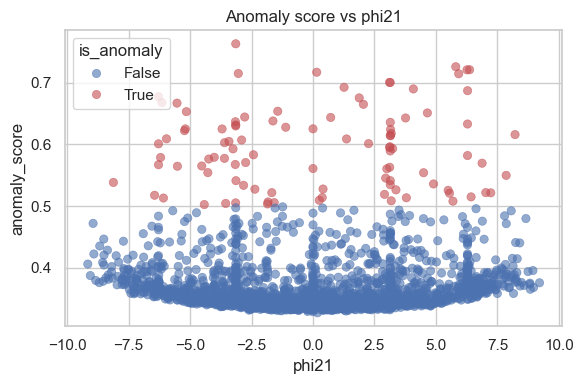

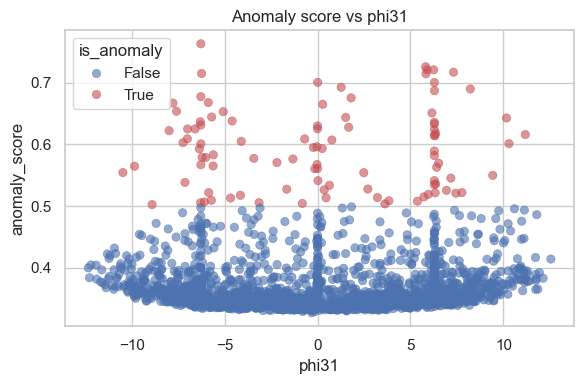

In [3]:
# Scatter plots: anomaly score vs each feature

# Optionally subsample for faster plotting
MAX_POINTS = 2000
if len(df) > MAX_POINTS:
    plot_df = df.sample(n=MAX_POINTS, random_state=42)
    print(f'Using random subsample of {MAX_POINTS} rows for plotting (of {len(df)})')
else:
    plot_df = df.copy()

for col in feature_cols:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(
        data=plot_df,
        x=col,
        y='anomaly_score',
        hue='is_anomaly',
        palette={False: 'C0', True: 'C3'},
        alpha=0.6,
        edgecolor=None,
    )
    plt.title(f'Anomaly score vs {col}')
    plt.tight_layout()
    plt.show()
